# 0. Getting setup

In [3]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12 or int(torch.__version__.split(".")[0]) == 2, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

torch version: 2.11.0+cu128
torchvision version: 0.26.0+cu128


In [4]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

[INFO] Couldn't find torchinfo... installing it.
[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4410, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 4410 (delta 5), reused 2 (delta 2), pack-reused 4399 (from 2)
Receiving objects: 100% (4410/4410), 764.18 MiB | 41.80 MiB/s, done.
Resolving deltas: 100% (2661/2661), done.
Updating files: 100% (248/248), done.


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# 1. Get Data

In [6]:
!pip install -q kagglehub

In [7]:
import kagglehub
from pathlib import Path

DATA_DIR = Path("/content/picksense/data/raw/openloris")
DATA_DIR.mkdir(parents=True, exist_ok=True)

path = kagglehub.dataset_download(
    "zhedamai/openlorisobject",
    output_dir=str(DATA_DIR)
)

print("Downloaded to:")
print(path)

100%|██████████| 18.2G/18.2G [03:52<00:00, 84.2MB/s]

Extracting files...


Downloaded to:
/content/picksense/data/raw/openloris


In [8]:
# Check if the dataset folder exists and list its contents
print("Dataset folder exists:", DATA_DIR.exists())

for item in DATA_DIR.iterdir():
    print(item.name)

Dataset folder exists: True
.complete
openloris


In [9]:
# List the first 100 files in the dataset directory
count = 0

for item in DATA_DIR.rglob("*"):
    print(item.relative_to(DATA_DIR))

    count += 1
    if count == 100:
        break

.complete
openloris
.complete/datasets
openloris/occlusion
openloris/sequence
openloris/illumination
openloris/clutter
openloris/pixel
.complete/datasets/zhedamai
.complete/datasets/zhedamai/openlorisobject
.complete/datasets/zhedamai/openlorisobject/2
.complete/datasets/zhedamai/openlorisobject/2/bundle.complete
openloris/occlusion/train
openloris/occlusion/test
openloris/sequence/train
openloris/sequence/validation
openloris/sequence/test
openloris/illumination/train
openloris/illumination/test
openloris/clutter/train
openloris/clutter/test
openloris/pixel/train
openloris/pixel/test
openloris/occlusion/train/task8
openloris/occlusion/train/task4
openloris/occlusion/train/task9
openloris/occlusion/train/task1
openloris/occlusion/train/note
openloris/occlusion/train/task3
openloris/occlusion/train/task7
openloris/occlusion/train/task2
openloris/occlusion/train/task5
openloris/occlusion/train/task6
openloris/occlusion/test/task8
openloris/occlusion/test/task4
openloris/occlusion/test/ta

In [10]:
from pathlib import Path

DATASET_DIR = Path(path)   # path returned by kagglehub

image_extensions = {".jpg", ".jpeg", ".png"}

images = [
    p for p in DATASET_DIR.rglob("*")
    if p.suffix.lower() in image_extensions
]

print("Number of image files found:", len(images))

print("\nFirst 10 images:")
for img_path in images[:10]:
    print(img_path)

Number of image files found: 404060

First 10 images:
/content/picksense/data/raw/openloris/openloris/occlusion/train/task8/cup_05/frame0202.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/train/task8/cup_05/frame0178.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/train/task8/cup_05/frame0143.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/train/task8/cup_05/frame0174.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/train/task8/cup_05/frame0187.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/train/task8/cup_05/frame0030.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/train/task8/cup_05/frame0200.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/train/task8/cup_05/frame0147.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/train/task8/cup_05/frame0224.jpg
/content/picksense/data/raw/openloris/openloris/occlusion/train/task8/cup_05/frame0226.jpg


Image path: /content/picksense/data/raw/openloris/openloris/occlusion/train/task8/cup_05/frame0202.jpg
Image size: (424, 240)


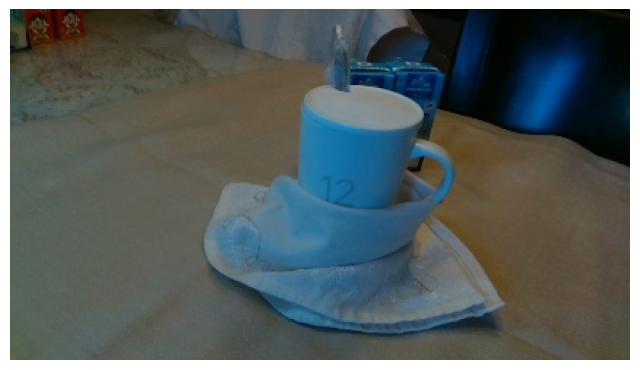

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = images[0]

img = Image.open(img_path)

print("Image path:", img_path)
print("Image size:", img.size)

plt.figure(figsize=(8, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [12]:
import os, shutil
from pathlib import Path

# --- locate OpenLORIS occlusion root (handles nested openloris/openloris) ---
BASE = Path("/content/picksense/data/raw/openloris")
OCC = [p for p in BASE.rglob("occlusion") if p.is_dir()][0]  # pick the first one
print("occlusion source:", OCC)

# --- 9 difficulty-ordered tasks -> occlusion % -> pickability label ---
TASK_TO_LABEL = {
     "task1": "clear",
    "task2": "clear",
    "task3": "clear",              # 0% occlusion

    "task4": "partially_occluded",
    "task5": "partially_occluded",
    "task6": "partially_occluded", # 25% occlusion

    "task7": "heavily_occluded",
    "task8": "heavily_occluded",
    "task9": "heavily_occluded"    # 50% occlusion
}

CLASSES = ["clear", "partially_occluded", "heavily_occluded"]

image_path = Path("/content/picksense/data/pickability_occlusion")
USE_SYMLINKS = True  # fast, no extra disk

def build_split(split):
    made = {c: 0 for c in CLASSES}
    for task_dir in sorted(p for p in (OCC / split).iterdir() if p.is_dir()):
        label = TASK_TO_LABEL.get(task_dir.name)
        if label is None:
            continue
        out_dir = image_path / split / label
        out_dir.mkdir(parents=True, exist_ok=True)
        for inst_dir in sorted(p for p in task_dir.iterdir() if p.is_dir()):
            for img in inst_dir.glob("*.jpg"):
                link = out_dir / f"{task_dir.name}__{inst_dir.name}__{img.name}"
                if link.exists() or link.is_symlink():
                    continue
                if USE_SYMLINKS:
                    os.symlink(img.resolve(), link)
                else:
                    shutil.copy2(img, link)
                made[label] += 1
    return made

if image_path.exists():
    shutil.rmtree(image_path)   # fresh build so counts are exact

for split in ["train", "test"]:
    counts = build_split(split)
    print(f"[{split}] linked:", counts, "total:", sum(counts.values()))

# --- FoodVision-style paths ---
train_dir = image_path / "train"
test_dir  = image_path / "test"
print("\nimage_path:", image_path)
print("train_dir :", train_dir)
print("test_dir  :", test_dir)

occlusion source: /content/picksense/data/raw/openloris/openloris/occlusion
[train] linked: {'clear': 14008, 'partially_occluded': 14214, 'heavily_occluded': 14008} total: 42230
[test] linked: {'clear': 1632, 'partially_occluded': 1656, 'heavily_occluded': 1632} total: 4920

image_path: /content/picksense/data/pickability_occlusion
train_dir : /content/picksense/data/pickability_occlusion/train
test_dir  : /content/picksense/data/pickability_occlusion/test


In [13]:
from torchvision import datasets
train_data = datasets.ImageFolder(train_dir)
test_data  = datasets.ImageFolder(test_dir)
print("classes:", train_data.classes)
print("train:", len(train_data), "| test:", len(test_data))
print("per-class train:", {c: train_data.targets.count(i) for i, c in enumerate(train_data.classes)})
print("per-class test:", {c: test_data.targets.count(i) for i, c in enumerate(test_data.classes)})

classes: ['clear', 'heavily_occluded', 'partially_occluded']
train: 42230 | test: 4920
per-class train: {'clear': 14008, 'heavily_occluded': 14008, 'partially_occluded': 14214}
per-class test: {'clear': 1632, 'heavily_occluded': 1632, 'partially_occluded': 1656}


# 2. Create Datasets and DataLoaders

### 2.1 Prepare transforms for images


In [14]:
# Create image size (from Table 3 in the ViT paper)
IMG_SIZE = 224

import torchvision.transforms as transforms
# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
print(f"Manually created transforms: {manual_transforms}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


### 2.2 Turn images into DataLoader's
Transforms created!

Let's now create our DataLoader's.

The ViT paper states the use of a batch size of 4096 which is 128x the size of the batch size we've been using (32).

However, we're going to stick with a batch size of 32.

In [15]:
# Set the batch size
BATCH_SIZE = 32 # this is lower than the ViT paper but it's because we're starting small

# Create data loaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms, # use manually created transforms
    batch_size=BATCH_SIZE
)

len(train_dataloader), len(test_dataloader), class_names

(1320, 154, ['clear', 'heavily_occluded', 'partially_occluded'])

### 2.3 Visualize a single image

In [16]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image from the batch
image, label = image_batch[0], label_batch[0]

# View the batch shapes
image.shape, label

(torch.Size([3, 224, 224]), tensor(1))

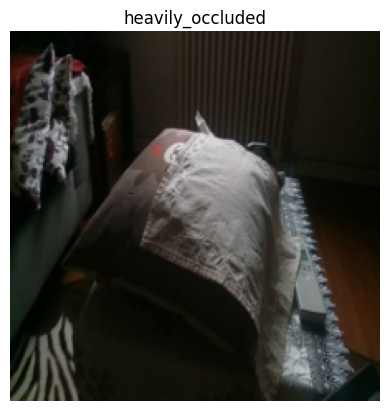

In [18]:
# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0)) # rearrange image dimensions to suit matplotlib [color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False);

# 3. Replicating the ViT paper: an overview

Looking at a whole machine learning paper can be overwhelming, especially if it's a new architecture or model. To make it easier to understand, let's break down the ViT paper into its core components.

* **inputs** - What goes into the model (e.g. images, text, audio, etc.)
* **outputs** - What comes out the model/layer/block? (in this case, i want the model to output classification labels)
* **layers** - Takes an inputs, manipulates it with a function(e.g could be self-attention)
* **blocks** - A collection of layers.
* **model** - A collection of blocks.

### 3.1 ViT overview: pieces of the puzzle

* firgure 1 : Visual overview of the architecture of the Vision Transformer (ViT) model. The model takes an image as input, splits it into patches, and then processes these patches through a series of transformer blocks to produce a final classification output.
* Four equations: math equations which define the functions of each layer/block.
* Table 1/3: different hyperparameters for the architecture/training.
* Text: description of the architecture and training process.

#### Figure 1
 ![](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/images/08-vit-paper-figure-1-architecture-overview.png?raw=true)

* Embedding = learnable representations (startt with random numbers and improve them over time)

## Section 3.1 Vision Transformer (ViT) Equations.

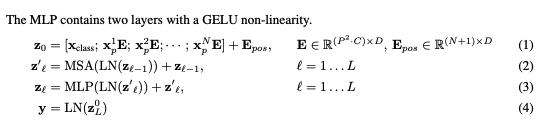

**Equeation 1**

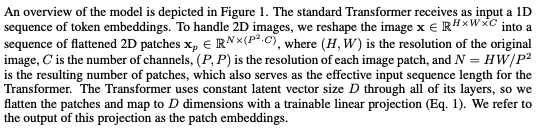

**Equation 1**

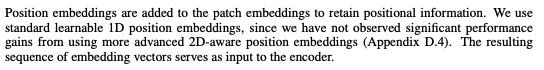




```python
x_input = [class_token, image_patch_1, image_patch_2, image_patch_3...] + [class_token_position, image_patch_1_position, image_patch_2_position, image_patch_3_position...]
```


**Equations 2 & 3**

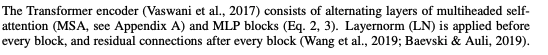


```python
# Equation 2
x_output_MSA_block = MSA_layer(LN_layer(x_input)) + x_input
```


```python
# Equation 3
x_output_MLP_block = MLP_layer(LN_layer(x_output_MSA_block)) + x_output_MSA_block
```



**Equation 4**

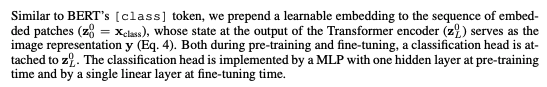

Note: MLP = Multi-Layer Perceptron = a neural network with at least 1 hidden layer.

```python
y = Linear_layer(LN_layer(x_output_MLP_block[0]))
```


### Table 1

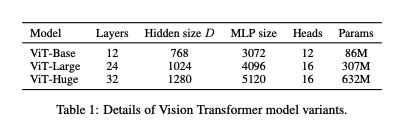


* ViT-Base, ViT-Large and ViT-Huge are all different sizes of the same architecture. The larger the model, the more parameters it has and the more data it needs to train effectively.
* layers - the number of transformer blocks in the model.
* Hidden size $D$ -  the embedding size of the model (the number of features in the input and output of each layer).
* MLP size - the number of neurons in the hidden layer of the MLP block.
* Heads - the number of attention heads in the multi-head self-attention (MSA) block.
* Parameters - the total number of trainable parameters in the model.










# 4. Equation 1: Split data into patches and creating the class, position and patch embedding

Layers = Input image -> Patch embedding -> Class embedding -> Position embedding (input -> function -> output)

What's the input shape?
* Input shape = (224,224,3) -> single image -> (height, width, color channels)

What is the output shape?
* Output shape = (num_patches + 1, embedding_dim) -> sequence of patch embeddings with class token


* Input shape: $H\times{W}\times{C}$ (height x width x color channels)
* Output shape: ${N\times\left(P^{2}\cdot{C}\right)}$

Where:
* H = height of the input image
* W = width of the input image
* C = color channels of the input image
* P = patch size (height and width of each patch)
* N = number of patches = (height * width) / p^2
* D = embedding dimension (the size of the vector representing each patch)



### 4.1 Calculating patch embedding input and output shapes by hand




In [19]:
# Create example values
height = 224 # H ("The training resolution is 224.")
width = 224 # W
color_channels = 3 # C
patch_size = 16 # P

# Calculate N (number of patches)
number_of_patches = int((height * width) / patch_size**2)
print(f"Number of patches (N) with image height (H={height}), width (W={width}) and patch size (P={patch_size}): {number_of_patches}")

Number of patches (N) with image height (H=224), width (W=224) and patch size (P=16): 196


In [20]:
# Input shape (this is the size of a single image)
embedding_layer_input_shape = (height, width, color_channels)

# Output shape
embedding_layer_output_shape = (number_of_patches, patch_size**2 * color_channels)

print(f"Input shape (single 2D image): {embedding_layer_input_shape}")
print(f"Output shape (single 2D image flattened into patches): {embedding_layer_output_shape}")

Input shape (single 2D image): (224, 224, 3)
Output shape (single 2D image flattened into patches): (196, 768)


### 4.2 Turning a single image into patches


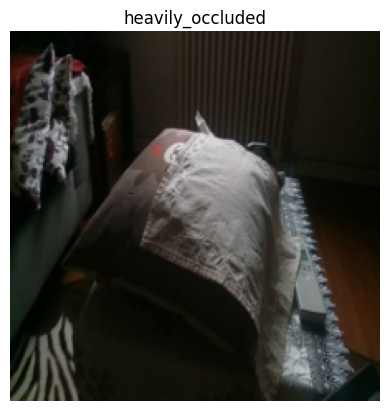

In [21]:
# View single image
plt.imshow(image.permute(1, 2, 0)) # adjust for matplotlib
plt.title(class_names[label])
plt.axis(False);

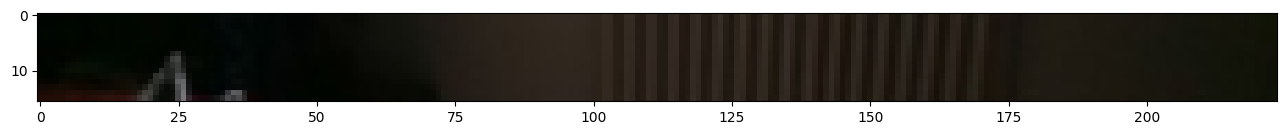

In [22]:
# Change image shape to be compatible with matplotlib (color_channels, height, width) -> (height, width, color_channels)
image_permuted = image.permute(1, 2, 0)

# Index to plot the top row of patched pixels
patch_size = 16
plt.figure(figsize=(patch_size, patch_size))
plt.imshow(image_permuted[:patch_size, :, :]);

In [23]:
image.shape

torch.Size([3, 224, 224])

Number of patches per row: 14.0
Patch size: 16 pixels x 16 pixels


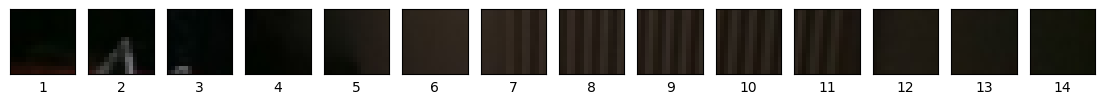

In [24]:
# Setup hyperparameters and make sure img_size and patch_size are compatible
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches}\nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=1,
                        ncols=img_size // patch_size, # one column for each patch
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Iterate through number of patches in the top row
for i, patch in enumerate(range(0, img_size, patch_size)):
    axs[i].imshow(image_permuted[:patch_size, patch:patch+patch_size, :]); # keep height index constant, alter the width index
    axs[i].set_xlabel(i+1) # set the label
    axs[i].set_xticks([])
    axs[i].set_yticks([])

Number of patches per row: 14.0        
Number of patches per column: 14.0        
Total patches: 196.0        
Patch size: 16 pixels x 16 pixels


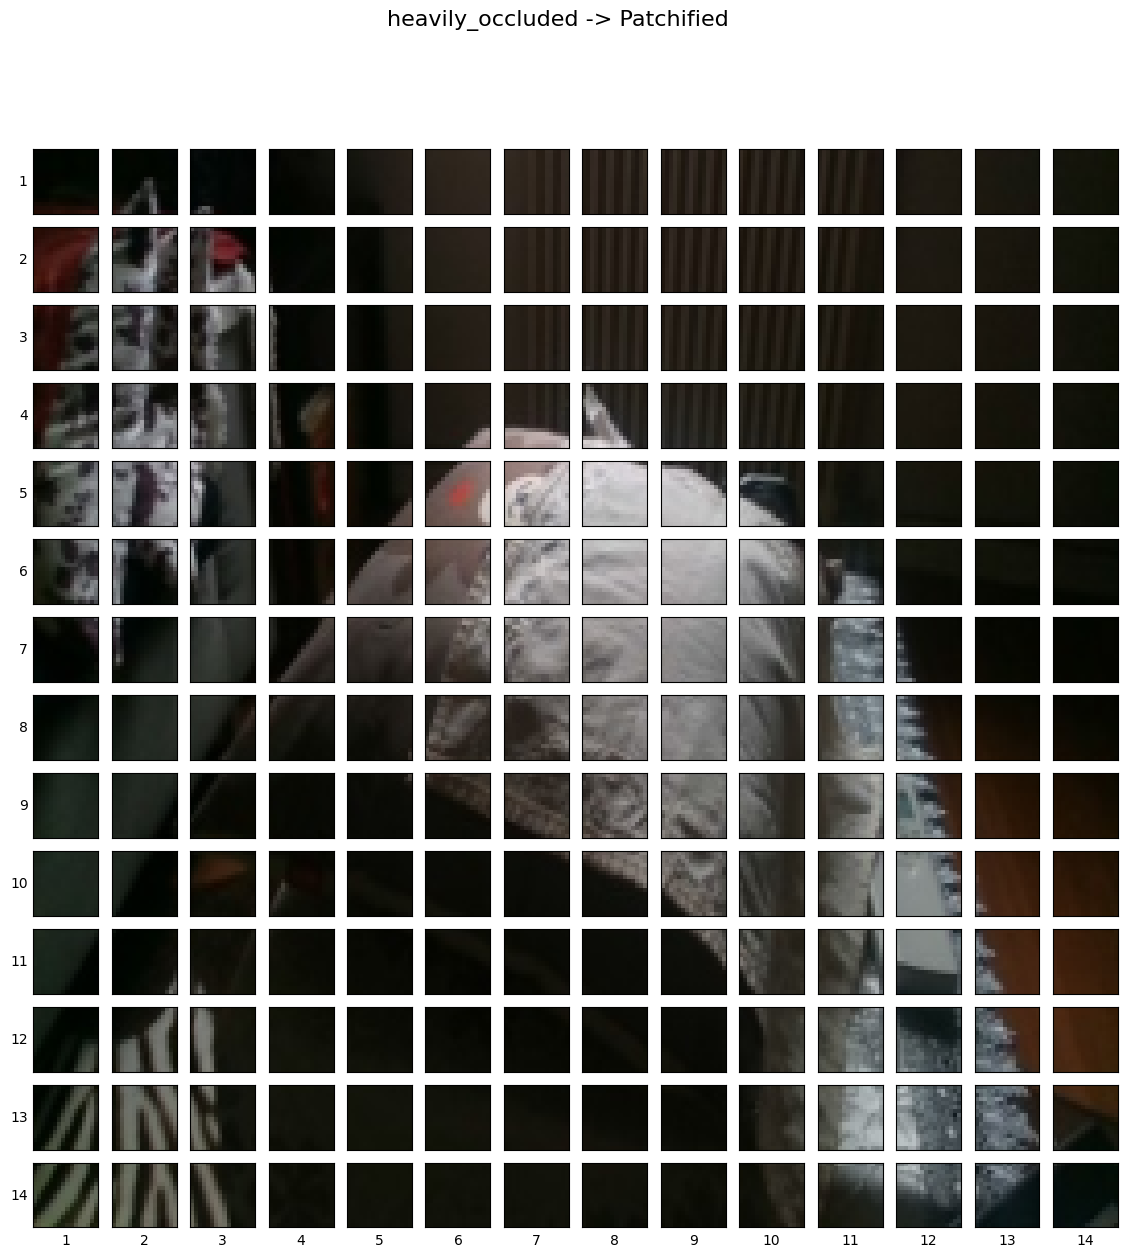

In [25]:
# Setup hyperparameters and make sure img_size and patch_size are compatible
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches}\
        \nNumber of patches per column: {num_patches}\
        \nTotal patches: {num_patches*num_patches}\
        \nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=img_size // patch_size, # need int not float
                        ncols=img_size // patch_size,
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Loop through height and width of image
for i, patch_height in enumerate(range(0, img_size, patch_size)): # iterate through height
    for j, patch_width in enumerate(range(0, img_size, patch_size)): # iterate through width

        # Plot the permuted image patch (image_permuted -> (Height, Width, Color Channels))
        axs[i, j].imshow(image_permuted[patch_height:patch_height+patch_size, # iterate through height
                                        patch_width:patch_width+patch_size, # iterate through width
                                        :]) # get all color channels

        # Set up label information, remove the ticks for clarity and set labels to outside
        axs[i, j].set_ylabel(i+1,
                             rotation="horizontal",
                             horizontalalignment="right",
                             verticalalignment="center")
        axs[i, j].set_xlabel(j+1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].label_outer()

# Set a super title
fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=16)
plt.show()

## 4.3 Creating image patches with `torch.nn.Conv2d()`
Perphaps we could creat the image patches and patch embedding in a single step using `torch.nn.Conv2d()` and setting the kernel size and stride parameters to `patch_size`. This would allow us to create the patches and embed them in a single step, rather than having to do it in two separate steps. 


In [26]:
# create conv2d layer to create patches and embed them in a single step
from torch import nn

#set the patch size
patch_size = 16

# Create a conv2d layer with hyperparameters to create patches and embed them in a single step

conv2d = nn.Conv2d(in_channels=3, # color channels
                   out_channels=768, # embedding dimension
                   kernel_size=patch_size, # patch size
                   stride=patch_size, # patch size
                   padding=0) 
conv2d

Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))

In [ ]:
# View single image shape
plt.imshow(image.permute(1, 2, 0)) # adjust for matplotlib
plt.title(class_names[label])
plt.axis(False);

In [27]:
# Pass the image through the convolutional layer.

image_out_of_conv = conv2d(image.unsqueeze(0)) # add batch dimension
print(image_out_of_conv.shape) # (batch_size, embedding_dimension, num_patches_height, num_patches_width)

torch.Size([1, 768, 14, 14])


Now we have passed a single image through the convolutional (`conv2d`) layer, let's check the output shape.

```python
torch.Size([1, 768, 14, 14]) # (batch_size, embedding_dimension, num_patches_height, num_patches_width)
```

In [28]:
image_out_of_conv.requires_grad

True

Showing random convolutional feature maps from indexes: [21, 27, 430, 120, 398]


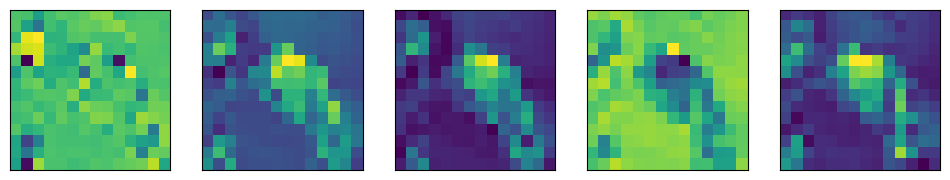

In [29]:
# Plot random 5 convolutional feature maps
import random
random_indexes = random.sample(range(0, 758), k=5) # pick 5 numbers between 0 and the embedding size
print(f"Showing random convolutional feature maps from indexes: {random_indexes}")

# Create plot
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(12, 12))

# Plot random image feature maps
for i, idx in enumerate(random_indexes):
    image_conv_feature_map = image_out_of_conv[:, idx, :, :] # index on the output tensor of the convolutional layer
    axs[i].imshow(image_conv_feature_map.squeeze().detach().numpy())
    axs[i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[]);

In [30]:
# Get a single feature map in tensor form
single_feature_map = image_out_of_conv[:, 0, :, :]
single_feature_map, single_feature_map.requires_grad

(tensor([[[-0.0400, -0.0936, -0.0979, -0.0334, -0.0584, -0.1072, -0.1294,
           -0.1280, -0.1275, -0.1051, -0.0829, -0.0936, -0.0771, -0.0664],
          [-0.1020, -0.1610, -0.2431, -0.0273, -0.0264, -0.1046, -0.1195,
           -0.1199, -0.1113, -0.1056, -0.1028, -0.0872, -0.0749, -0.0614],
          [-0.0109, -0.2197, -0.1770,  0.0335, -0.0229, -0.0870, -0.1060,
           -0.1140, -0.0955, -0.0830, -0.0780, -0.0861, -0.0728, -0.0649],
          [-0.2317, -0.2797, -0.2062, -0.1019, -0.0164,  0.0281, -0.1452,
           -0.4173, -0.1148, -0.1071, -0.0785, -0.0833, -0.0700, -0.0621],
          [-0.1638, -0.0915, -0.0289, -0.0399,  0.0205, -0.1769, -0.3997,
           -0.5348, -0.5510, -0.2191, -0.0738, -0.0775, -0.0592, -0.0520],
          [ 0.0585,  0.0222, -0.1262, -0.0365, -0.1861, -0.2111, -0.4460,
           -0.4188, -0.4111, -0.4468, -0.1146, -0.0533, -0.0626, -0.0420],
          [-0.0168, -0.0489, -0.1765, -0.0883, -0.1181, -0.1139, -0.4008,
           -0.2953, -0.3593, -0.

### 4.4 Flattening the patch embeddings with `torch.flatten()`
Right now there are a series of convolutional feature maps (patch embeddings) that I want to flatten into a sequence of patch embedding to satisfy the input criteria of the ViT Transformer Encoder.


In [ ]:
# Current tensor shape
print(f"Current tensor shape: {image_out_of_conv.shape} -> [batch, embedding_dim, feature_map_height, feature_map_width]")

Want : (batch_size, num_patches, embedding_dimension) = (1, 196, 768)

In [31]:
# Create flatten layer
flatten = nn.Flatten(start_dim=2, # flatten feature_map_height (dimension 2)
                     end_dim=3) # flatten feature_map_width (dimension 3)
flatten(image_out_of_conv).shape

torch.Size([1, 768, 196])

Original image shape: torch.Size([3, 224, 224])
Image feature map shape: torch.Size([1, 768, 14, 14])
Flattened image feature map shape: torch.Size([1, 768, 196])


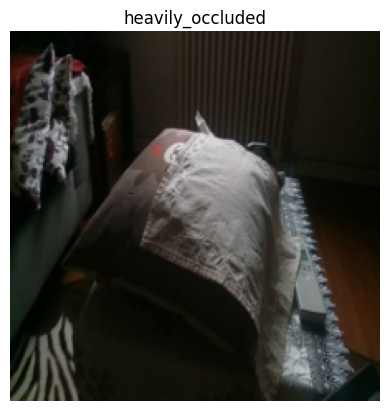

In [32]:
# 1. View single image
plt.imshow(image.permute(1, 2, 0)) # adjust for matplotlib
plt.title(class_names[label])
plt.axis(False);
print(f"Original image shape: {image.shape}")

# 2. Turn image into feature maps
image_out_of_conv = conv2d(image.unsqueeze(0)) # add batch dimension to avoid shape errors
print(f"Image feature map shape: {image_out_of_conv.shape}")

# 3. Flatten the feature maps
image_out_of_conv_flattened = flatten(image_out_of_conv)
print(f"Flattened image feature map shape: {image_out_of_conv_flattened.shape}")

In [33]:
# Get flattened image patch embeddings in right shape
image_out_of_conv_flattened_reshaped = image_out_of_conv_flattened.permute(0, 2, 1) # [batch_size, P^2•C, N] -> [batch_size, N, P^2•C]
print(f"Patch embedding sequence shape: {image_out_of_conv_flattened_reshaped.shape} -> [batch_size, num_patches, embedding_size]")

Patch embedding sequence shape: torch.Size([1, 196, 768]) -> [batch_size, num_patches, embedding_size]


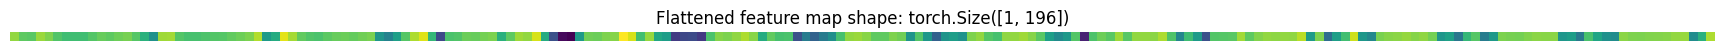

In [34]:
# Get a single flattened feature map
single_flattened_feature_map = image_out_of_conv_flattened.permute(0, 2, 1)[:, :, 0] # index: (batch_size, number_of_patches, embedding_dimension)

# Plot the flattened feature map visually
plt.figure(figsize=(22, 22))
plt.imshow(single_flattened_feature_map.detach().numpy())
plt.title(f"Flattened feature map shape: {single_flattened_feature_map.shape}")
plt.axis(False);

In [35]:
# See the flattened feature map as a tensor
single_flattened_feature_map, single_flattened_feature_map.requires_grad, single_flattened_feature_map.shape

(tensor([[-0.0400, -0.0936, -0.0979, -0.0334, -0.0584, -0.1072, -0.1294, -0.1280,
          -0.1275, -0.1051, -0.0829, -0.0936, -0.0771, -0.0664, -0.1020, -0.1610,
          -0.2431, -0.0273, -0.0264, -0.1046, -0.1195, -0.1199, -0.1113, -0.1056,
          -0.1028, -0.0872, -0.0749, -0.0614, -0.0109, -0.2197, -0.1770,  0.0335,
          -0.0229, -0.0870, -0.1060, -0.1140, -0.0955, -0.0830, -0.0780, -0.0861,
          -0.0728, -0.0649, -0.2317, -0.2797, -0.2062, -0.1019, -0.0164,  0.0281,
          -0.1452, -0.4173, -0.1148, -0.1071, -0.0785, -0.0833, -0.0700, -0.0621,
          -0.1638, -0.0915, -0.0289, -0.0399,  0.0205, -0.1769, -0.3997, -0.5348,
          -0.5510, -0.2191, -0.0738, -0.0775, -0.0592, -0.0520,  0.0585,  0.0222,
          -0.1262, -0.0365, -0.1861, -0.2111, -0.4460, -0.4188, -0.4111, -0.4468,
          -0.1146, -0.0533, -0.0626, -0.0420, -0.0168, -0.0489, -0.1765, -0.0883,
          -0.1181, -0.1139, -0.4008, -0.2953, -0.3593, -0.2979, -0.2481, -0.1198,
          -0.040

## 4.5 Turning the ViT patch embedding layer into a PyTorch module

* 1) Create a class called `PatchEmbedding` 
* 2) Initialize with appropriate hyperparameters, such as channel size, patch size and embedding dimension.
* 3) Create a layer to turn an image into patches using `nn.Conv2d()` (just like in 4.3 above).
* 4) Create a layer to flatten the patch feature maps into a single dimension (just like in 4.4 above).
* 5) Define a `forward()` method to take an input and pass it through the layers created in 3 and 4.
* 6) Make sure the output shape reflects the required output shape of the ViT architecture (${N \times\left(P^{2} \cdot C\right)}$).

In [36]:
# 1. Create a class which subclasses nn.Module
class PatchEmbedding(nn.Module):
    """Turns a 2D input image into a 1D sequence learnable embedding vector.

    Args:
        in_channels (int): Number of color channels for the input images. Defaults to 3.
        patch_size (int): Size of patches to convert input image into. Defaults to 16.
        embedding_dim (int): Size of embedding to turn image into. Defaults to 768.
    """
    # 2. Initialize the class with appropriate variables
    def __init__(self,
                 in_channels:int=3,
                 patch_size:int=16,
                 embedding_dim:int=768):
        super().__init__()

        self.patch_size = patch_size

        # 3. Create a layer to turn an image into patches
        self.patcher = nn.Conv2d(in_channels=in_channels,
                                 out_channels=embedding_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size,
                                 padding=0)

        # 4. Create a layer to flatten the patch feature maps into a single dimension
        self.flatten = nn.Flatten(start_dim=2, # only flatten the feature map dimensions into a single vector
                                  end_dim=3)

    # 5. Define the forward method
    def forward(self, x):
        # Create assertion to check that inputs are the correct shape
        image_resolution = x.shape[-1]
        assert image_resolution % patch_size == 0, f"Input image size must be divisible by patch size, image shape: {image_resolution}, patch size: {patch_size}"

        # Perform the forward pass
        x_patched = self.patcher(x)
        x_flattened = self.flatten(x_patched)
        # 6. Make sure the output shape has the right order
        return x_flattened.permute(0, 2, 1) # adjust so the embedding is on the final dimension [batch_size, P^2•C, N] -> [batch_size, N, P^2•C]

In [38]:
set_seeds()

# Create a instance of patch embedding layer
patchify = PatchEmbedding(in_channels=3,
                        patch_size=16,
                        embedding_dim=768)
#Pass a single image through the patch embedding layer
print(f"Input image shape: {image.unsqueeze(0).shape}")
patch_embedded_image = patchify(image.unsqueeze(0)) # add an extra batch dimension to the image
print(f"Output patch embedding shape: {patch_embedded_image.shape} -> [batch_size, num_patches, embedding_dimension]")

Input image shape: torch.Size([1, 3, 224, 224])
Output patch embedding shape: torch.Size([1, 196, 768]) -> [batch_size, num_patches, embedding_dimension]


In [ ]:
# Create random input sizes
random_input_image = (1, 3, 224, 224)
random_input_image_error = (1, 3, 250, 250) # will error because image size is incompatible with patch_size

# # Get a summary of the input and outputs of PatchEmbedding (uncomment for full output)
summary(PatchEmbedding(),
        input_size=random_input_image, # try swapping this for "random_input_image_error"
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

### 4.6 Creating the class token embedding

Want to : prepend a learnable class token embedding to the sequence of patch embeddings. This class token will be used to represent the entire image and will be the input to the final classification layer.



In [ ]:
patch_embedded_image

In [ ]:
# View the patch embedding and patch embedding shape
print(patch_embedded_image)
print(f"Patch embedding shape: {patch_embedded_image.shape} -> [batch_size, number_of_patches, embedding_dimension]")

In [ ]:
# Get the batch size and embedding dimension
batch_size = patch_embedded_image.shape[0]
embedding_dimension = patch_embedded_image.shape[-1]

# Create the class token embedding as a learnable parameter that shares the same size as the embedding dimension (D)
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension), # [batch_size, number_of_tokens, embedding_dimension]
                           requires_grad=True) # make sure the embedding is learnable

# Show the first 10 examples of the class_token
print(class_token[:, :, :10])

# Print the class_token shape
print(f"Class token shape: {class_token.shape} -> [batch_size, number_of_tokens, embedding_dimension]")

In [ ]:
# Add the class token embedding to the front of the patch embedding
patch_embedded_image_with_class_embedding = torch.cat((class_token, patch_embedded_image),
                                                      dim=1) # concat on first dimension

# Print the sequence of patch embeddings with the prepended class token embedding
print(patch_embedded_image_with_class_embedding)
print(f"Sequence of patch embeddings with class token prepended shape: {patch_embedded_image_with_class_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

In [ ]:
random_image_tensor = torch.rand((1, 3, 224, 224)) # [batch_size, color_channels, height, width]
rand_image_tensor_bad = torch.randn(1,3, 250, 250) # [batch_size, color_channels, height, width] - will error because image size is incompatible with patch_size

patchify(random_image_tensor)

### Creating a position embedding

Want to: Create a series of 1D learnable position embeddings to add to the sequence of patch embeddings. This will allow the model to understand the spatial relationships between the patches in the image.



In [ ]:
# View the sequence of patch embeddings with the prepended class token embedding
# View the sequence of patch embeddings with the prepended class embedding
patch_embedded_image_with_class_embedding, patch_embedded_image_with_class_embedding.shape


In [ ]:
# Calculate N (number of patches)
number_of_patches = int((height * width) / patch_size**2)

# Get embedding dimension
embedding_dimension = patch_embedded_image_with_class_embedding.shape[2]

# Create the learnable 1D position embedding
position_embedding = nn.Parameter(torch.ones(1,
                                             number_of_patches+1,
                                             embedding_dimension),
                                  requires_grad=True) # make sure it's learnable

# Show the first 10 sequences and 10 position embedding values and check the shape of the position embedding
print(position_embedding[:, :10, :10])
print(f"Position embedding shape: {position_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

In [ ]:
# Add the position embedding to the patch and class token embedding
patch_and_position_embedding = patch_embedded_image_with_class_embedding + position_embedding
print(patch_and_position_embedding)
print(f"Patch embeddings, class token prepended and positional embeddings added shape: {patch_and_position_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

### 4.8 Putting it all together: from image to embedding
We've written code to turn an image into a flattened sequence of patch embeddings with a prepended class token embedding and added position embeddings. The output shape should be (batch_size, num_patches + 1, embedding_dimension) = (1, 197, 768) for a single image.



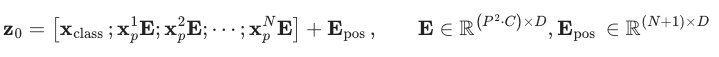

In [ ]:
set_seeds()

# 1. Set patch size
patch_size = 16

# 2. Print shape of original image tensor and get the image dimensions
print(f"Image tensor shape: {image.shape}")
height, width = image.shape[1], image.shape[2]

# 3. Get image tensor and add batch dimension
x = image.unsqueeze(0)
print(f"Input image with batch dimension shape: {x.shape}")

# 4. Create patch embedding layer
patch_embedding_layer = PatchEmbedding(in_channels=3,
                                       patch_size=patch_size,
                                       embedding_dim=768)

# 5. Pass image through patch embedding layer
patch_embedding = patch_embedding_layer(x)
print(f"Patching embedding shape: {patch_embedding.shape}")

# 6. Create class token embedding
batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[-1]
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension),
                           requires_grad=True) # make sure it's learnable
print(f"Class token embedding shape: {class_token.shape}")

# 7. Prepend class token embedding to patch embedding
patch_embedding_class_token = torch.cat((class_token, patch_embedding), dim=1)
print(f"Patch embedding with class token shape: {patch_embedding_class_token.shape}")

# 8. Create position embedding
number_of_patches = int((height * width) / patch_size**2)
position_embedding = nn.Parameter(torch.ones(1, number_of_patches+1, embedding_dimension),
                                  requires_grad=True) # make sure it's learnable

# 9. Add position embedding to patch embedding with class token
patch_and_position_embedding = patch_embedding_class_token + position_embedding
print(f"Patch and position embedding shape: {patch_and_position_embedding.shape}")

#  5. Equation 2: Multi-Head Attention (MSA)

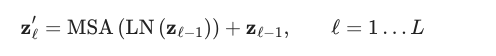

* Multi-Head Self Attention (MSA) - `torch.nn.MultiheadAttention()`, which part of a sequence should pay the most attention to when making predictions.
 - In our case, we have a series of embedded image patches, where one patch significantly relates to another patch.
 - We want our neural network (ViT) to learn this relationship/representation.
* Norm (LN or LayerNorm) - `torch.nn.LayerNorm()`, is a technique to normalize the distributions of intermediate layers. It enables smoother gradients, faster training and better generalization.
    - Normalization = make everything have the same mean and same standard deviation.

* Residual connection - add the input to output. It helps to prevent the vanishing gradient problem and allows training of deeper networks.


In [ ]:
class MultiHeadSelfAttentionBlock(nn.Module):
    """Multi-head self-attention layer.

    Args:
        embedding_dim (int): Size of the embedding dimension. Defaults to 768.
        num_heads (int): Number of attention heads. Defaults to 12.
        dropout (float): Dropout probability. Defaults to 0.1.
    """
    def __init__(self,
                 embedding_dim:int=768,
                 num_heads:int=12,
                 attn_dropout:float=0.1):
        super().__init__()

    # Create the norn layer (LN)
        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)
        self.multihead_attn = nn.MultiheadAttention(embed_dim=embedding_dim,
                                                    num_heads=num_heads,
                                                    dropout=attn_dropout,
                                                    batch_first=True) # batch_first=True to avoid permuting the input

    def forward(self, x):
        # x: (batch_size, seq_len, embedding_dim) because batch_first=True
        attn_output, _ = self.multihead_attn(query=x, key=x, value=x, need_weights=False) # don't need the attention weights
        x = x + attn_output  # Residual connection
        x = self.layer_norm(x)
        return x

In [ ]:
# Create an instance of MSABlock
multihead_self_attention_block = MultiHeadSelfAttentionBlock(embedding_dim=768, # from Table 1
                                                             num_heads=12) # from Table 1

# Pass patch and position image embedding through MSABlock
patched_image_through_msa_block = multihead_self_attention_block(patch_and_position_embedding)
print(f"Input shape of MSA block: {patch_and_position_embedding.shape}")
print(f"Output shape MSA block: {patched_image_through_msa_block.shape}")

# 6. Equation 3: Multilayer Perceptron (MLP)


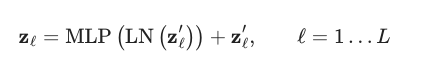


* **MLP** - Multi-Layer Perceptron, a neural network with at least one hidden layer. In the ViT paper, the MLP block consists of two linear layers with a GELU activation function in between.
 * MLP = a quite broad term for block with a series of layer(s), layers can be linear, convolutional, recurrent, etc. The MLP block in the ViT paper is a specific type of MLP block that consists of two linear layers with a GELU activation function in between.
 * Layers can mean: fully-connected layers, convolutional layers, recurrent layers, etc. In the case of the MLP block in the ViT paper, it refers to fully-connected layers.
 * Dropout - a regularization technique to prevent overfitting by randomly setting a fraction of the input units to 0 at each update during training time, which helps to prevent overfitting. In the ViT paper, dropout is applied after each linear layer in the MLP block.

 In pseudocode:

 ``` python
  #MLP block =
 x  = linear -> non-linear -> dropout -> linear -> dropout
 ```



In [ ]:
# 1. Create a class that inherits from nn.Module
class MLPBlock(nn.Module):
    """Creates a layer normalized multilayer perceptron block ("MLP block" for short)."""
    # 2. Initialize the class with hyperparameters from Table 1 and Table 3
    def __init__(self,
                 embedding_dim:int=768, # Hidden Size D from Table 1 for ViT-Base
                 mlp_size:int=3072, # MLP size from Table 1 for ViT-Base
                 dropout:float=0.1): # Dropout from Table 3 for ViT-Base
        super().__init__()

        # 3. Create the Norm layer (LN)
        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        # 4. Create the Multilayer perceptron (MLP) layer(s)
        self.mlp = nn.Sequential(
            nn.Linear(in_features=embedding_dim,
                      out_features=mlp_size),
            nn.GELU(), # "The MLP contains two layers with a GELU non-linearity (section 3.1)."
            nn.Dropout(p=dropout),
            nn.Linear(in_features=mlp_size, # needs to take same in_features as out_features of layer above
                      out_features=embedding_dim), # take back to embedding_dim
            nn.Dropout(p=dropout) # "Dropout, when used, is applied after every dense layer.."
        )

    # 5. Create a forward() method to pass the data through the layers
    def forward(self, x):
        x = self.layer_norm(x)
        x = self.mlp(x)
        
        return x

In [ ]:
# Create an instance of MLPBlock
mlp_block = MLPBlock(embedding_dim=768, # from Table 1
                     mlp_size=3072, # from Table 1
                     dropout=0.1) # from Table 3

# Pass output of MSABlock through MLPBlock
patched_image_through_mlp_block = mlp_block(patched_image_through_msa_block)
print(f"Input shape of MLP block: {patched_image_through_msa_block.shape}")
print(f"Output shape MLP block: {patched_image_through_mlp_block.shape}")


# 7. Create the Transformer Encoder
The Transformer Encoder is a combination of alternating blocks of MSA (Equation 2) and MLP (Equation 3).

And there are residual connections between each block.

* Encoder = turn a sequence into learnable representations
* Decoder = go from learn representations back to a sequence (e.g. for text generation, image generation, etc.)
* Residual connection = add a layer input to its subsequent output, this enables the creation of deeper networks (prevents weights from getting too small)


```python
# Transformer Encoder
x_input -> MSA_block -> [MSA_block_output + x_input] -> MLP_block -> [MLP_block_output + MSA_block_output + x_input] -> ...
```



### 7.1  Creating a Transformer Encoder by combining our custom made layers

In [ ]:
# 1. Create a class that inherits from nn.Module
class TransformerEncoderBlock(nn.Module):
    """Creates a Transformer Encoder block."""
    # 2. Initialize the class with hyperparameters from Table 1 and Table 3
    def __init__(self,
                 embedding_dim:int=768, # Hidden size D from Table 1 for ViT-Base
                 num_heads:int=12, # Heads from Table 1 for ViT-Base
                 mlp_size:int=3072, # MLP size from Table 1 for ViT-Base
                 mlp_dropout:float=0.1, # Amount of dropout for dense layers from Table 3 for ViT-Base
                 attn_dropout:float=0): # Amount of dropout for attention layers
        super().__init__()

        # 3. Create MSA block (equation 2)
        self.msa_block = MultiHeadSelfAttentionBlock(embedding_dim=embedding_dim,
                                                     num_heads=num_heads,
                                                     attn_dropout=attn_dropout)

        # 4. Create MLP block (equation 3)
        self.mlp_block =  MLPBlock(embedding_dim=embedding_dim,
                                   mlp_size=mlp_size,
                                   dropout=mlp_dropout)

    # 5. Create a forward() method
    def forward(self, x):

        # 6. Create residual connection for MSA block (add the input to the output)
        x =  self.msa_block(x) + x

        # 7. Create residual connection for MLP block (add the input to the output)
        x = self.mlp_block(x) + x

        return x

In [ ]:
# Create an instance of TransformerEncoderBlock
transformer_encoder_block = TransformerEncoderBlock()

# # Print an input and output summary of our Transformer Encoder (uncomment for full output)
summary(model=transformer_encoder_block,
        input_size=(1, 197, 768), # (batch_size, num_patches, embedding_dimension)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

### 7.2 Creating a Transformer Encoder with PyTorch's Transformer layers

In [ ]:
# Create the same as above with torch.nn.TransformerEncoderLayer()
torch_transformer_encoder_layer = nn.TransformerEncoderLayer(d_model=768, # Hidden size D from Table 1 for ViT-Base
                                                             nhead=12, # Heads from Table 1 for ViT-Base
                                                             dim_feedforward=3072, # MLP size from Table 1 for ViT-Base
                                                             dropout=0.1, # Amount of dropout for dense layers from Table 3 for ViT-Base
                                                             activation="gelu", # GELU non-linear activation
                                                             batch_first=True, # Do our batches come first?
                                                             norm_first=True) # Normalize first or after MSA/MLP layers?

torch_transformer_encoder_layer

In [ ]:
## Get the output of PyTorch's version of the Transformer Encoder (uncomment for full output)
summary(model=torch_transformer_encoder_layer,
        input_size=(1, 197, 768), # (batch_size, num_patches, embedding_dimension)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

# 8. Putting it all together to create ViT



In [ ]:
# 1. Create a ViT class that inherits from nn.Module
class ViT(nn.Module):
    """Creates a Vision Transformer architecture with ViT-Base hyperparameters by default."""
    # 2. Initialize the class with hyperparameters from Table 1 and Table 3
    def __init__(self,
                 img_size:int=224, # Training resolution from Table 3 in ViT paper
                 in_channels:int=3, # Number of channels in input image
                 patch_size:int=16, # Patch size
                 num_transformer_layers:int=12, # Layers from Table 1 for ViT-Base
                 embedding_dim:int=768, # Hidden size D from Table 1 for ViT-Base
                 mlp_size:int=3072, # MLP size from Table 1 for ViT-Base
                 num_heads:int=12, # Heads from Table 1 for ViT-Base
                 attn_dropout:float=0, # Dropout for attention projection
                 mlp_dropout:float=0.1, # Dropout for dense/MLP layers
                 embedding_dropout:float=0.1, # Dropout for patch and position embeddings
                 num_classes:int=1000): # Default for ImageNet but can customize this
        super().__init__() # don't forget the super().__init__()!

        # 3. Make the image size is divisible by the patch size
        assert img_size % patch_size == 0, f"Image size must be divisible by patch size, image size: {img_size}, patch size: {patch_size}."

        # 4. Calculate number of patches (height * width/patch^2)
        self.num_patches = (img_size * img_size) // patch_size**2

        # 5. Create learnable class embedding (needs to go at front of sequence of patch embeddings)
        self.class_embedding = nn.Parameter(data=torch.randn(1, 1, embedding_dim),
                                            requires_grad=True)

        # 6. Create learnable position embedding
        self.position_embedding = nn.Parameter(data=torch.randn(1, self.num_patches+1, embedding_dim),
                                               requires_grad=True)

        # 7. Create embedding dropout value
        self.embedding_dropout = nn.Dropout(p=embedding_dropout)

        # 8. Create patch embedding layer
        self.patch_embedding = PatchEmbedding(in_channels=in_channels,
                                              patch_size=patch_size,
                                              embedding_dim=embedding_dim)

        # 9. Create Transformer Encoder blocks (we can stack Transformer Encoder blocks using nn.Sequential())
        # Note: The "*" means "all"
        self.transformer_encoder = nn.Sequential(*[TransformerEncoderBlock(embedding_dim=embedding_dim,
                                                                            num_heads=num_heads,
                                                                            mlp_size=mlp_size,
                                                                            mlp_dropout=mlp_dropout) for _ in range(num_transformer_layers)])

        # 10. Create classifier head
        self.classifier = nn.Sequential(
            nn.LayerNorm(normalized_shape=embedding_dim),
            nn.Linear(in_features=embedding_dim,
                      out_features=num_classes)
        )

    # 11. Create a forward() method
    def forward(self, x):

        # 12. Get batch size
        batch_size = x.shape[0]

        # 13. Create class token embedding and expand it to match the batch size (equation 1)
        class_token = self.class_embedding.expand(batch_size, -1, -1) # "-1" means to infer the dimension (try this line on its own)

        # 14. Create patch embedding (equation 1)
        x = self.patch_embedding(x)

        # 15. Concat class embedding and patch embedding (equation 1)
        x = torch.cat((class_token, x), dim=1)

        # 16. Add position embedding to patch embedding (equation 1)
        x = self.position_embedding + x

        # 17. Run embedding dropout (Appendix B.1)
        x = self.embedding_dropout(x)

        # 18. Pass patch, position and class embedding through transformer encoder layers (equations 2 & 3)
        x = self.transformer_encoder(x)

        # 19. Put 0 index logit through classifier (equation 4)
        x = self.classifier(x[:, 0]) # run on each sample in a batch at 0 index

        return x